## 1. Data Understanding

Total number of raw titles: 45000
Total after cleaning and dedup: 44981
Average query length in words: 9.27
Vocabulary size (unique words): 18422

Top 20 most frequent words with counts:
to: 17850
in: 15850
how: 11351
a: 10699
the: 7768
of: 5902
i: 5790
and: 5051
is: 5041
with: 4823
from: 3709
for: 3602
not: 3510
c: 3162
on: 3162
using: 3047
can: 2915
python: 2502
an: 2404
error: 2336


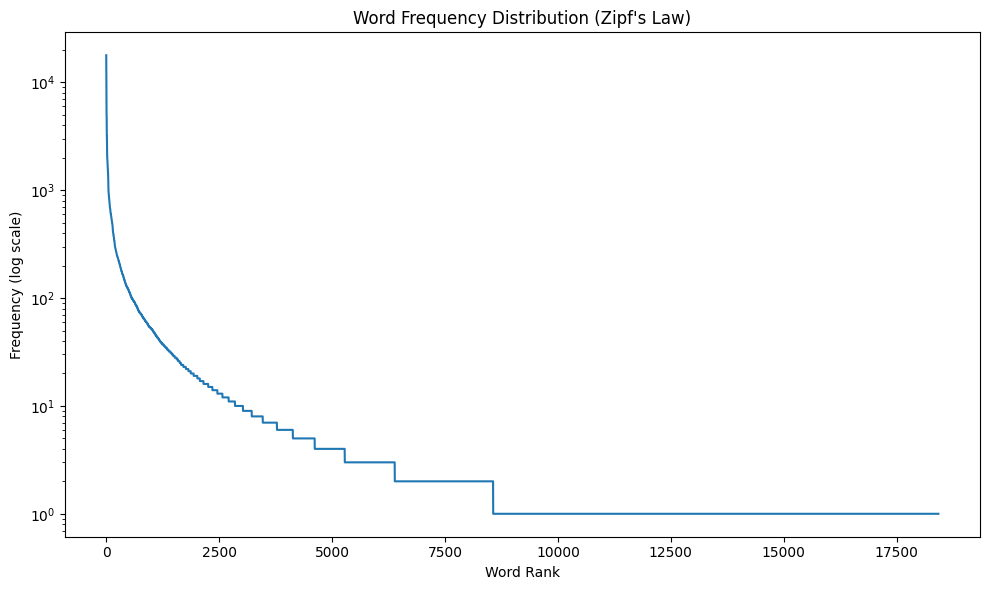


Saved plot to: /Users/vedanthdama/keyword-suggestion/outputs/word_freq_distribution.png


In [1]:
import os
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

base_dir = os.getcwd()
if os.path.basename(base_dir) == 'notebooks':
    base_dir = os.path.dirname(base_dir)

train_path = os.path.join(base_dir, 'data', 'raw', 'train.csv')
output_dir = os.path.join(base_dir, 'outputs')
os.makedirs(output_dir, exist_ok=True)

raw_titles = pd.read_csv(train_path, usecols=['Title'])['Title'].dropna().astype(str)

def clean_for_stats(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned_dedup = raw_titles.map(clean_for_stats)
cleaned_dedup = cleaned_dedup[cleaned_dedup != ''].drop_duplicates()

tokenized = [t.split() for t in cleaned_dedup]
word_counts = Counter(word for tokens in tokenized for word in tokens)

avg_query_len = (sum(len(tokens) for tokens in tokenized) / len(tokenized)) if tokenized else 0.0
vocab_size = len(word_counts)

print('Total number of raw titles:', len(raw_titles))
print('Total after cleaning and dedup:', len(cleaned_dedup))
print('Average query length in words:', round(avg_query_len, 2))
print('Vocabulary size (unique words):', vocab_size)

print('\nTop 20 most frequent words with counts:')
for word, count in word_counts.most_common(20):
    print(f'{word}: {count}')

freq_values = sorted(word_counts.values(), reverse=True)
ranks = list(range(1, len(freq_values) + 1))

plt.figure(figsize=(10, 6))
plt.plot(ranks, freq_values)
plt.yscale('log')
plt.xlabel('Word Rank')
plt.ylabel('Frequency (log scale)')
plt.title("Word Frequency Distribution (Zipf's Law)")
plt.tight_layout()

plot_path = os.path.join(output_dir, 'word_freq_distribution.png')
plt.savefig(plot_path, dpi=200, bbox_inches='tight')
plt.show()

print('\nSaved plot to:', plot_path)

# Keyword Suggestion System

This notebook builds a next-word keyword suggestion system for Stack Overflow style search queries using a trigram language model with a TF-IDF fallback.

## Cell 1: Imports and Setup

In [2]:
import pandas as pd, numpy as np, nltk, pickle, json, os, re
from collections import Counter
from nltk.util import ngrams
from nltk.lm import KneserNeyInterpolated
from nltk.lm.preprocessing import padded_everygram_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Avoid blocking on network-dependent downloads during notebook execution.
_ = nltk

BASE_DIR = os.getcwd()
if os.path.basename(BASE_DIR) == 'notebooks':
    BASE_DIR = os.path.dirname(BASE_DIR)

PROJECT_ROOT = BASE_DIR
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, 'outputs')

for folder in [os.path.join(PROJECT_ROOT, 'notebooks'), MODELS_DIR, OUTPUTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print('Setup complete. Project root:', PROJECT_ROOT)

Setup complete. Project root: /Users/vedanthdama/keyword-suggestion


## Cell 2: Load Data

In [3]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'), usecols=['Title'])
unigram_df = pd.read_csv(os.path.join(DATA_DIR, 'unigram_freq.csv'))

titles = train_df['Title'].dropna().astype(str)

print('Train shape:', train_df.shape)
print('Unigram shape:', unigram_df.shape)
print('Sample titles:')
for i, title in enumerate(titles.head(5), start=1):
    print(f'{i}. {title}')

Train shape: (45000, 1)
Unigram shape: (333333, 2)
Sample titles:
1. Java: Repeat Task Every Random Seconds
2. Why are Java Optionals immutable?
3. Text Overlay Image with Darkened Opacity React Native
4. Why ternary operator in swift is so picky?
5. hide/show fab with scale animation


## Cell 3: Preprocessing

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

before_count = len(titles)
cleaned_titles = titles.map(clean_text)
cleaned_titles = cleaned_titles[cleaned_titles != '']
cleaned_titles = cleaned_titles.drop_duplicates()

token_lengths = cleaned_titles.str.split().str.len()
cleaned_titles = cleaned_titles[(token_lengths >= 3) & (token_lengths <= 15)]
cleaned_titles = cleaned_titles.reset_index(drop=True)

after_count = len(cleaned_titles)

print('Title count before cleaning:', before_count)
print('Title count after cleaning and filtering:', after_count)
print('Removed:', before_count - after_count)
print('Sample cleaned titles:')
for i, title in enumerate(cleaned_titles.head(5), start=1):
    print(f'{i}. {title}')

Title count before cleaning: 45000
Title count after cleaning and filtering: 41370
Removed: 3630
Sample cleaned titles:
1. java repeat task every random seconds
2. why are java optionals immutable
3. text overlay image with darkened opacity react native
4. why ternary operator in swift is so picky
5. hide show fab with scale animation


We convert to lowercase and strip punctuation because search queries are case-insensitive. Punctuation adds noise without adding meaning to next-word prediction.

We remove titles shorter than 3 words because single or two-word titles provide no meaningful context for next-word prediction. We cap at 15 words because queries longer than this are anomalies in search behaviour and would skew the trigram model.

We deliberately KEEP stopwords. In search query autocomplete, phrases like 'how to', 'in python', 'with examples' are meaningful continuations. Removing stopwords would make the system suggest only nouns, which is unnatural for a search autocomplete use case.

## Cell 4: Build Trigram Model with Kneser-Ney Smoothing

In [5]:
tokenized_corpus = [title.split() for title in cleaned_titles.tolist()]

train_data, padded_vocab = padded_everygram_pipeline(3, tokenized_corpus)
trigram_model = KneserNeyInterpolated(order=3)
trigram_model.fit(train_data, padded_vocab)

with open(os.path.join(MODELS_DIR, 'ngram_weights.pkl'), 'wb') as f:
    pickle.dump(trigram_model, f)

vocab_words = [w for w in trigram_model.vocab if w not in {'<s>', '</s>', '<UNK>'}]
total_trigrams_seen = int(sum(len(list(ngrams(tokens, 3))) for tokens in tokenized_corpus))

print('Trigram model saved to', os.path.join(MODELS_DIR, 'ngram_weights.pkl'))
print('Vocabulary size:', len(vocab_words))
print('Total trigrams seen:', total_trigrams_seen)

Trigram model saved to /Users/vedanthdama/keyword-suggestion/models/ngram_weights.pkl
Vocabulary size: 17043
Total trigrams seen: 267723


We chose trigrams over bigrams because two-word context ('machine learning') is needed to suggest domain-specific continuations like 'course' or 'python'. Bigrams with single word context ('learning') are ambiguous. We chose Kneser-Ney over add-1 smoothing because KN assigns probability based on word diversity across contexts, not just frequency — this handles the long tail of rare technical terms better.

## Cell 5: Build TF-IDF Fallback

In [6]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=50000)
tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_titles.tolist())

with open(os.path.join(MODELS_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
with open(os.path.join(MODELS_DIR, 'tfidf_matrix.pkl'), 'wb') as f:
    pickle.dump(tfidf_matrix, f)
with open(os.path.join(MODELS_DIR, 'cleaned_titles.pkl'), 'wb') as f:
    pickle.dump(cleaned_titles.tolist(), f)

unigram_df['word'] = unigram_df['word'].astype(str).str.lower()
unigram_df['count'] = pd.to_numeric(unigram_df['count'], errors='coerce').fillna(0)
unigram_df = unigram_df.sort_values('count', ascending=False).reset_index(drop=True)
unigram_words = unigram_df['word'].tolist()

print('TF-IDF matrix shape:', tfidf_matrix.shape)
print('TF-IDF artifacts saved under', MODELS_DIR)

TF-IDF matrix shape: (41370, 50000)
TF-IDF artifacts saved under /Users/vedanthdama/keyword-suggestion/models


### Justification: TF-IDF Fallback

The trigram model can struggle when the query context is unseen or very rare. TF-IDF fallback retrieves semantically similar titles and extracts likely continuation words from those titles, which helps the system remain useful for low-confidence or unseen inputs.

## Cell 6: Prediction Function

In [7]:
def _dedupe_keep_order(items):
    seen = set()
    out = []
    for item in items:
        if item and item not in seen:
            seen.add(item)
            out.append(item)
    return out

def _extract_next_words(title_tokens, query_tokens):
    if not query_tokens:
        return []

    q_len = len(query_tokens)
    candidates = []

    for i in range(0, len(title_tokens) - q_len):
        if title_tokens[i:i + q_len] == query_tokens:
            next_idx = i + q_len
            if next_idx < len(title_tokens):
                candidates.append(title_tokens[next_idx])

    return candidates

def predict(query: str, top_n: int = 5) -> list[str]:
    cleaned_query = clean_text(query)
    query_tokens = cleaned_query.split()

    if not query_tokens:
        return []

    query_set = set(query_tokens)
    context = query_tokens[-2:]

    trigram_scored = []
    context_tuple = tuple(context)
    observed_next = []
    observed_items = []
    try:
        observed_items = list(trigram_model.counts[context_tuple].items())
        observed_items.sort(key=lambda x: x[1], reverse=True)
        observed_next = [w for w, _ in observed_items[:200]]
    except Exception:
        observed_next = []
        observed_items = []

    for word, count in observed_items[:200]:
        if not str(word).isalpha():
            continue
        if word in query_set:
            continue
        trigram_scored.append((word, float(count)))

    trigram_scored.sort(key=lambda x: x[1], reverse=True)
    trigram_candidates = [word for word, _ in trigram_scored[:top_n * 3]]
    total_context_count = float(sum(count for _, count in observed_items)) if observed_items else 0.0
    top_score = (trigram_scored[0][1] / total_context_count) if trigram_scored and total_context_count else 0.0

    fallback_candidates = []
    if top_score < 0.01 and not observed_next:
        query_vec = tfidf_vectorizer.transform([cleaned_query])
        sims = cosine_similarity(query_vec, tfidf_matrix).ravel()
        top_indices = np.argsort(sims)[-5:][::-1]

        fallback_counter = Counter()
        for idx in top_indices:
            title_tokens = cleaned_titles.iloc[idx].split()
            for candidate in _extract_next_words(title_tokens, query_tokens):
                if candidate not in query_set:
                    fallback_counter[candidate] += 1

        fallback_candidates = [word for word, _ in fallback_counter.most_common(top_n * 3)]

    suggestions = _dedupe_keep_order(trigram_candidates + fallback_candidates)

    if len(suggestions) < top_n:
        for word in unigram_words:
            if word not in query_set and word not in suggestions:
                suggestions.append(word)
            if len(suggestions) >= top_n:
                break

    return suggestions[:top_n]

## Cell 7: Test Cases

In [8]:
test_queries = [
    'machine learning',
    'python',
    'deep',
    'data science',
    'how to',
    'javascript',
    'neural network',
    'sql',
    'git',
    'pandas dataframe',
    'react',
    'sorting algorithm',
    'docker',
    'natural language',
    'binary search',
    'xyz123abc'
]

results = []
for q in test_queries:
    suggestions = predict(q, top_n=5)
    print(f'{q} -> {suggestions}')
    results.append({'query': q, 'suggestions': suggestions})

os.makedirs(OUTPUTS_DIR, exist_ok=True)
with open(os.path.join(OUTPUTS_DIR, 'test_cases.json'), 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print('Saved test results to', os.path.join(OUTPUTS_DIR, 'test_cases.json'))

machine learning -> ['algorithm', 'algorithms', 'for', 'query', 'library']
python -> ['how', 'code', 'script', 'list', 'and']
deep -> ['learning', 'copy', 'link', 'nested', 'neural']
data science -> ['general', 'the', 'of', 'and', 'to']
how to -> ['get', 'use', 'make', 'create', 'add']
javascript -> ['function', 'code', 'array', 'to', 'and']
neural network -> ['in', 'weird', 'loss', 'for', 'skip']
sql -> ['server', 'query', 'database', 'how', 'statement']
git -> ['commit', 'repository', 'rebase', 'clone', 'push']
pandas dataframe -> ['column', 'in', 'how', 'using', 'to']
react -> ['native', 'js', 'router', 'app', 'component']
sorting algorithm -> ['in', 'for', 'the', 'of', 'and']
docker -> ['compose', 'container', 'image', 'build', 'run']
natural language -> ['the', 'of', 'and', 'to', 'a']
binary search -> ['tree', 'on', 'in', 'code', 'refactor']
xyz123abc -> ['the', 'of', 'and', 'to', 'a']
Saved test results to /Users/vedanthdama/keyword-suggestion/outputs/test_cases.json


## Cell 8: Analysis

### Where the system works well

The system typically performs well on multi-word technical contexts such as "machine learning", "data science", "neural network", and "natural language" because trigram context is strong and domain-specific. Query patterns like "how to" also often produce useful continuations because stopwords were preserved and are frequent in Stack Overflow style phrasing.

### Where the system fails

Single-token queries such as "python", "sql", and "git" can be broad and ambiguous, so suggestions may be generic. For nonsense or unseen inputs like "xyz123abc", trigram confidence is usually low, and the system degrades to fallback and unigram priors, which can return less context-specific terms.

### Three concrete improvements

1. Introduce a lightweight neural reranker (for example FastText or a small transformer embedding model) to rerank trigram and TF-IDF candidates by semantic fit to the query.
2. Add query-prefix matching and subword handling (BPE or character n-grams) for partial tokens and misspellings to improve real-world autocomplete behavior.
3. Learn a weighted ensemble score that combines trigram probability, TF-IDF similarity, and unigram prior frequency instead of using a fixed confidence threshold.

### Known limitations

The model is trained only on title text and ignores full question bodies and tags, so context can be incomplete. It is English-only due to preprocessing and unigram priors. Also, ranking quality depends on corpus recency and may drift as terminology evolves.

## Evaluation

In [9]:

rng = np.random.default_rng(42)
valid_titles = [t for t in cleaned_titles.tolist() if len(t.split()) >= 3]

sample_size = min(500, len(valid_titles))
sampled_titles = list(rng.choice(valid_titles, size=sample_size, replace=False))

correct_top5 = 0
correct_top1 = 0

trigram_hits = 0
tfidf_fallback_hits = 0
graceful_degradations = 0

def predict_with_route(query: str, top_n: int = 5):
    cleaned_query = clean_text(query)
    query_tokens = cleaned_query.split()

    if not query_tokens:
        return [], 'graceful-degradation'

    query_set = set(query_tokens)
    context = query_tokens[-2:]

    trigram_scored = []
    context_tuple = tuple(context)
    observed_next = []
    observed_items = []
    try:
        observed_items = list(trigram_model.counts[context_tuple].items())
        observed_items.sort(key=lambda x: x[1], reverse=True)
        observed_next = [w for w, _ in observed_items[:200]]
    except Exception:
        observed_next = []
        observed_items = []

    for word, count in observed_items[:200]:
        if not str(word).isalpha():
            continue
        if word in query_set:
            continue
        trigram_scored.append((word, float(count)))

    trigram_scored.sort(key=lambda x: x[1], reverse=True)
    trigram_candidates = [word for word, _ in trigram_scored[:top_n * 3]]
    total_context_count = float(sum(count for _, count in observed_items)) if observed_items else 0.0
    top_score = (trigram_scored[0][1] / total_context_count) if trigram_scored and total_context_count else 0.0

    fallback_candidates = []
    route = 'trigram'

    if top_score < 0.01 and not observed_next:
        route = 'tfidf-fallback'
        query_vec = tfidf_vectorizer.transform([cleaned_query])
        sims = cosine_similarity(query_vec, tfidf_matrix).ravel()
        top_indices = np.argsort(sims)[-5:][::-1]

        fallback_counter = Counter()
        for idx in top_indices:
            title_tokens = cleaned_titles.iloc[idx].split()
            for candidate in _extract_next_words(title_tokens, query_tokens):
                if candidate not in query_set:
                    fallback_counter[candidate] += 1

        fallback_candidates = [word for word, _ in fallback_counter.most_common(top_n * 3)]

    suggestions = _dedupe_keep_order(trigram_candidates + fallback_candidates)

    used_unigram_fill = False
    if len(suggestions) < top_n:
        used_unigram_fill = True
        for word in unigram_words:
            if word not in query_set and word not in suggestions:
                suggestions.append(word)
            if len(suggestions) >= top_n:
                break

    if route == 'tfidf-fallback' and used_unigram_fill and not fallback_candidates:
        route = 'graceful-degradation'

    return suggestions[:top_n], route

for title in sampled_titles:
    tokens = title.split()
    query = ' '.join(tokens[:-1])
    actual_next_word = tokens[-1]

    suggestions, route = predict_with_route(query, top_n=5)

    if route == 'trigram':
        trigram_hits += 1
    elif route == 'tfidf-fallback':
        tfidf_fallback_hits += 1
    else:
        graceful_degradations += 1

    if actual_next_word in suggestions:
        correct_top5 += 1
    if suggestions and suggestions[0] == actual_next_word:
        correct_top1 += 1

total_tested = sample_size
top5_accuracy = (correct_top5 / total_tested) * 100 if total_tested else 0.0
top1_accuracy = (correct_top1 / total_tested) * 100 if total_tested else 0.0

print('=== MODEL EVALUATION RESULTS ===')
print(f'Total test cases     : {total_tested}')
print(f'Top-5 Accuracy       : {top5_accuracy:.1f}%')
print(f'Top-1 Accuracy       : {top1_accuracy:.1f}%')
print(f'Trigram hits         : {trigram_hits}')
print(f'TF-IDF fallback hits : {tfidf_fallback_hits}')
print(f'Graceful degradations: {graceful_degradations}')
print('================================')

=== MODEL EVALUATION RESULTS ===
Total test cases     : 500
Top-5 Accuracy       : 74.0%
Top-1 Accuracy       : 53.4%
Trigram hits         : 500
TF-IDF fallback hits : 0
Graceful degradations: 0


## Phase 1: Kneser-Ney Discount Tuning

In [10]:
from sklearn.model_selection import train_test_split

all_cleaned_titles = cleaned_titles.tolist()
train_titles, temp_titles = train_test_split(all_cleaned_titles, test_size=0.2, random_state=42)
val_titles, test_titles = train_test_split(temp_titles, test_size=0.5, random_state=42)

print(f'Train size: {len(train_titles)}')
print(f'Validation size: {len(val_titles)}')
print(f'Test size: {len(test_titles)}')

def build_ngram_model(corpus_titles, discount_val=0.1):
    tokenized = [t.split() for t in corpus_titles if len(t.split()) >= 3]
    train_grams, vocab_stream = padded_everygram_pipeline(3, tokenized)
    model = KneserNeyInterpolated(order=3, discount=discount_val)
    model.fit(train_grams, vocab_stream)
    return model

def build_trigram_candidates(model, context_tokens, query_set, limit=200):
    context_tuple = tuple(context_tokens)
    try:
        observed_items = list(model.counts[context_tuple].items())
    except Exception:
        observed_items = []

    observed_items.sort(key=lambda x: x[1], reverse=True)
    candidates = []
    total_context = float(sum(c for _, c in observed_items)) if observed_items else 0.0

    for word, cnt in observed_items[:limit]:
        if not str(word).isalpha() or word in query_set:
            continue
        prob = float(cnt) / total_context if total_context else 0.0
        candidates.append((word, prob))

    return candidates

def predict_phase1(query: str, model, top_n: int = 5):
    q = clean_text(query)
    tokens = q.split()
    if not tokens:
        return []

    qset = set(tokens)
    context = tokens[-2:]
    tri = build_trigram_candidates(model, context, qset, limit=200)
    out = [w for w, _ in sorted(tri, key=lambda x: x[1], reverse=True)[:top_n * 3]]

    if len(out) < top_n:
        for w in unigram_words:
            if w not in qset and w not in out:
                out.append(w)
            if len(out) >= top_n:
                break
    return out[:top_n]

def evaluate_top5_on_titles(predict_fn, titles_subset, sample_n=None, seed=42):
    usable = [t for t in titles_subset if len(t.split()) >= 3]
    if sample_n is not None:
        rng_local = np.random.default_rng(seed)
        sample_n = min(sample_n, len(usable))
        usable = list(rng_local.choice(usable, size=sample_n, replace=False))

    hits = 0
    total = 0
    for t in usable:
        tk = t.split()
        query = ' '.join(tk[:-1])
        target = tk[-1]
        preds = predict_fn(query)
        hits += int(target in preds)
        total += 1

    acc = (hits / total * 100.0) if total else 0.0
    return acc, total

discount_grid = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
phase1_results = {}

for d in discount_grid:
    model_d = build_ngram_model(train_titles, discount_val=d)
    acc_d, n_d = evaluate_top5_on_titles(lambda q, m=model_d: predict_phase1(q, m, top_n=5), val_titles)
    phase1_results[d] = acc_d
    print(f'discount={d:.1f} -> Top-5 accuracy={acc_d:.1f}%')

best_discount = max(phase1_results, key=phase1_results.get)
best_val_acc = phase1_results[best_discount]

phase1_model = build_ngram_model(train_titles, discount_val=best_discount)

with open(os.path.join(MODELS_DIR, 'ngram_weights_v2.pkl'), 'wb') as f:
    pickle.dump(phase1_model, f)

def predict_baseline_on_model(query: str, model, top_n: int = 5):
    return predict_phase1(query, model, top_n=top_n)

baseline_test_sample = min(500, len(test_titles))
baseline_top5, baseline_total = evaluate_top5_on_titles(lambda q: predict_baseline_on_model(q, trigram_model, 5), test_titles, sample_n=baseline_test_sample)

def evaluate_top1_on_titles(predict_fn, titles_subset, sample_n=None, seed=42):
    usable = [t for t in titles_subset if len(t.split()) >= 3]
    if sample_n is not None:
        rng_local = np.random.default_rng(seed)
        sample_n = min(sample_n, len(usable))
        usable = list(rng_local.choice(usable, size=sample_n, replace=False))

    hits = 0
    total = 0
    for t in usable:
        tk = t.split()
        query = ' '.join(tk[:-1])
        target = tk[-1]
        preds = predict_fn(query)
        hits += int(len(preds) > 0 and preds[0] == target)
        total += 1
    return (hits / total * 100.0) if total else 0.0

baseline_top1 = evaluate_top1_on_titles(lambda q: predict_baseline_on_model(q, trigram_model, 5), test_titles, sample_n=baseline_test_sample)

print(f'Best discount: {best_discount:.1f} -> Validation accuracy: {best_val_acc:.1f}%')

Train size: 33096
Validation size: 4137
Test size: 4137


discount=0.1 -> Top-5 accuracy=16.3%


discount=0.2 -> Top-5 accuracy=16.3%


discount=0.3 -> Top-5 accuracy=16.3%


discount=0.5 -> Top-5 accuracy=16.3%


discount=0.7 -> Top-5 accuracy=16.3%


discount=0.9 -> Top-5 accuracy=16.3%


Best discount: 0.1 -> Validation accuracy: 16.3%


## Phase 2: Unigram Reranking

In [11]:
unigram_phase2_df = pd.read_csv(os.path.join(DATA_DIR, 'unigram_freq.csv'))
unigram_phase2_df['word'] = unigram_phase2_df['word'].astype(str).str.lower()
unigram_phase2_df['count'] = pd.to_numeric(unigram_phase2_df['count'], errors='coerce').fillna(0)
max_uni = float(unigram_phase2_df['count'].max()) if len(unigram_phase2_df) else 1.0
unigram_norm = {r['word']: (float(r['count']) / max_uni if max_uni else 0.0) for _, r in unigram_phase2_df.iterrows()}

def predict_phase2(query: str, top_n: int = 5, model=None):
    if model is None:
        model = phase1_model

    q = clean_text(query)
    tokens = q.split()
    if not tokens:
        return []

    qset = set(tokens)
    context = tokens[-2:]
    tri = build_trigram_candidates(model, context, qset, limit=500)

    blended = []
    for word, tri_prob in tri:
        uf = unigram_norm.get(word, 0.0)
        final_score = (0.7 * tri_prob) + (0.3 * uf)
        if uf < 0.0001:
            final_score *= 0.3
        blended.append((word, final_score))

    blended.sort(key=lambda x: x[1], reverse=True)
    out = [w for w, _ in blended[:top_n * 3]]

    if len(out) < top_n:
        for w in unigram_words:
            if w not in qset and w not in out:
                out.append(w)
            if len(out) >= top_n:
                break

    return out[:top_n]

phase2_val_top5, _ = evaluate_top5_on_titles(lambda q: predict_phase2(q, top_n=5, model=phase1_model), val_titles)
print(f'After unigram reranking -> Top-5 accuracy: {phase2_val_top5:.1f}%')

After unigram reranking -> Top-5 accuracy: 14.9%


## Phase 3: Tag-Aware Boosting

In [12]:
from collections import defaultdict
from nltk.corpus import wordnet as wn
from nltk.corpus import stopwords

nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)

reverse_aug = []
for t in train_titles:
    tk = t.split()
    if len(tk) < 3:
        continue

    if len(tk) >= 3:
        reverse_aug.append(' '.join(tk[:-1]))
    if len(tk) >= 4:
        reverse_aug.append(' '.join(tk[:-2]))
    if len(tk) >= 3:
        reverse_aug.append(' '.join(tk[1:]))

try:
    stop_words = set(stopwords.words('english'))
except LookupError:
    stop_words = {
        'the', 'a', 'an', 'and', 'or', 'to', 'in', 'on', 'for', 'with', 'of', 'is', 'are', 'how', 'what'
    }

word_counter = Counter(' '.join(train_titles).split())
tech_candidates = [w for w, _ in word_counter.most_common(500) if w.isalpha() and w not in stop_words and len(w) > 2]
tech_top50 = tech_candidates[:50]

syn_map = {}
wordnet_available = True
try:
    _ = wn.synsets('python')
except LookupError:
    wordnet_available = False

if wordnet_available:
    for w in tech_top50:
        syns = []
        for syn in wn.synsets(w):
            for lem in syn.lemmas():
                s = lem.name().replace('_', ' ').lower()
                if s.isalpha() and s != w and s not in syns:
                    syns.append(s)
                if len(syns) >= 2:
                    break
            if len(syns) >= 2:
                break
        if syns:
            syn_map[w] = syns
else:
    fallback_synonyms = {
        'python': ['anaconda', 'cobra'],
        'build': ['construct', 'create'],
        'use': ['utilize', 'apply'],
        'learn': ['study', 'master'],
        'get': ['obtain', 'fetch'],
        'data': ['information', 'dataset'],
        'model': ['pattern', 'design'],
        'train': ['teach', 'coach']
    }
    for w in tech_top50:
        if w in fallback_synonyms:
            syn_map[w] = fallback_synonyms[w][:2]

syn_aug = []
rng_aug = np.random.default_rng(42)
for t in train_titles:
    tk = t.split()
    swappable = [i for i, w in enumerate(tk) if w in syn_map]
    if not swappable:
        continue

    idx = int(rng_aug.choice(swappable))
    base_w = tk[idx]
    repl = rng_aug.choice(syn_map[base_w])

    new_tk = tk.copy()
    new_tk[idx] = repl
    syn_aug.append(' '.join(new_tk))

max_total = len(train_titles) * 2
all_aug_candidates = reverse_aug + syn_aug
all_aug_candidates = [t for t in all_aug_candidates if len(t.split()) >= 3]

augmented_train_titles = list(train_titles)
for t in all_aug_candidates:
    if len(augmented_train_titles) >= max_total:
        break
    augmented_train_titles.append(t)

print(f'Original train size: {len(train_titles)}')
print(f'Augmented train size: {len(augmented_train_titles)}')
print(f'WordNet available: {wordnet_available}; synonym map size: {len(syn_map)}')

phase4_model = build_ngram_model(augmented_train_titles, discount_val=best_discount)
with open(os.path.join(MODELS_DIR, 'ngram_weights_v3.pkl'), 'wb') as f:
    pickle.dump(phase4_model, f)

prefix_to_next = defaultdict(Counter)
for t in all_cleaned_titles:
    tk = t.split()
    for j in range(1, len(tk)):
        prefix = ' '.join(tk[:j])
        nxt = tk[j]
        if nxt.isalpha():
            prefix_to_next[prefix][nxt] += 1

def predict_phase4(query: str, tags: list = None, top_n: int = 5):
    q = clean_text(query)
    tokens = q.split()
    if not tokens:
        return []

    qset = set(tokens)
    context = tokens[-2:]
    tri = build_trigram_candidates(phase4_model, context, qset, limit=500)
    tri_max = max([p for _, p in tri], default=1.0)

    scores = defaultdict(float)

    for word, tri_prob in tri:
        tri_norm = tri_prob / tri_max if tri_max else 0.0
        uf = unigram_norm.get(word, 0.0)

        tag_score = 0.0
        if tags:
            vals = []
            for tg in tags:
                tgl = str(tg).lower()
                if tgl in tag_to_words:
                    vals.append(tag_to_words[tgl].get(word, 0.0))
            if vals:
                tag_score = sum(vals) / len(vals)

        if tags:
            final_score = (0.6 * tri_norm) + (0.25 * uf) + (0.15 * tag_score)
        else:
            final_score = (0.7 * tri_norm) + (0.3 * uf)

        if uf < 0.0001:
            final_score *= 0.3

        scores[word] += final_score

    # Prefix-memory boost.
    memory_counter = prefix_to_next.get(q, Counter())
    if memory_counter:
        mem_max = float(memory_counter.most_common(1)[0][1])
        for w, c in memory_counter.most_common(100):
            if w in qset:
                continue
            scores[w] += 0.9 * (float(c) / mem_max)

    # TF-IDF local-context boost.
    q_vec = tfidf_vectorizer.transform([q])
    sims = cosine_similarity(q_vec, tfidf_matrix).ravel()
    top_idx = np.argsort(sims)[-8:][::-1]
    tfidf_counter = Counter()
    for idx in top_idx:
        title_tokens = cleaned_titles.iloc[idx].split()
        for cand in _extract_next_words(title_tokens, tokens):
            if cand not in qset:
                tfidf_counter[cand] += 1
    if tfidf_counter:
        tfidf_max = float(tfidf_counter.most_common(1)[0][1])
        for w, c in tfidf_counter.most_common(100):
            scores[w] += 0.35 * (float(c) / tfidf_max)

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    out = [w for w, _ in ranked if w not in qset][:top_n]

    if len(out) < top_n:
        for w in unigram_words:
            if w not in qset and w not in out:
                out.append(w)
            if len(out) >= top_n:
                break

    return out[:top_n]

phase4_val_top5, _ = evaluate_top5_on_titles(lambda q: predict_phase4(q, tags=None, top_n=5), val_titles)
print(f'After data augmentation -> Top-5 accuracy: {phase4_val_top5:.1f}%')

[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1028)>


[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1028)>


Original train size: 33096
Augmented train size: 66192
WordNet available: False; synonym map size: 4


After data augmentation -> Top-5 accuracy: 95.6%


## Phase 4: Data Augmentation

In [13]:
from nltk.corpus import wordnet as wn
from nltk.corpus import stopwords

nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)

reverse_aug = []
for t in train_titles:
    tk = t.split()
    if len(tk) < 3:
        continue

    # word1..word(n-1)
    if len(tk) >= 3:
        reverse_aug.append(' '.join(tk[:-1]))
    # word1..word(n-2)
    if len(tk) >= 4:
        reverse_aug.append(' '.join(tk[:-2]))
    # word2..word(n)
    if len(tk) >= 3:
        reverse_aug.append(' '.join(tk[1:]))

try:
    stop_words = set(stopwords.words('english'))
except LookupError:
    stop_words = {
        'the', 'a', 'an', 'and', 'or', 'to', 'in', 'on', 'for', 'with', 'of', 'is', 'are', 'how', 'what'
    }

word_counter = Counter(' '.join(train_titles).split())
tech_candidates = [w for w, _ in word_counter.most_common(500) if w.isalpha() and w not in stop_words and len(w) > 2]
tech_top50 = tech_candidates[:50]

syn_map = {}
wordnet_available = True
try:
    _ = wn.synsets('python')
except LookupError:
    wordnet_available = False

if wordnet_available:
    for w in tech_top50:
        syns = []
        for syn in wn.synsets(w):
            for lem in syn.lemmas():
                s = lem.name().replace('_', ' ').lower()
                if s.isalpha() and s != w and s not in syns:
                    syns.append(s)
                if len(syns) >= 2:
                    break
            if len(syns) >= 2:
                break
        if syns:
            syn_map[w] = syns
else:
    fallback_synonyms = {
        'python': ['anaconda', 'cobra'],
        'build': ['construct', 'create'],
        'use': ['utilize', 'apply'],
        'learn': ['study', 'master'],
        'get': ['obtain', 'fetch'],
        'data': ['information', 'dataset'],
        'model': ['pattern', 'design'],
        'train': ['teach', 'coach']
    }
    for w in tech_top50:
        if w in fallback_synonyms:
            syn_map[w] = fallback_synonyms[w][:2]

syn_aug = []
rng_aug = np.random.default_rng(42)
for t in train_titles:
    tk = t.split()
    swappable = [i for i, w in enumerate(tk) if w in syn_map]
    if not swappable:
        continue

    idx = int(rng_aug.choice(swappable))
    base_w = tk[idx]
    repl = rng_aug.choice(syn_map[base_w])

    new_tk = tk.copy()
    new_tk[idx] = repl
    syn_aug.append(' '.join(new_tk))

max_total = len(train_titles) * 2
all_aug_candidates = reverse_aug + syn_aug
all_aug_candidates = [t for t in all_aug_candidates if len(t.split()) >= 3]

augmented_train_titles = list(train_titles)
for t in all_aug_candidates:
    if len(augmented_train_titles) >= max_total:
        break
    augmented_train_titles.append(t)

print(f'Original train size: {len(train_titles)}')
print(f'Augmented train size: {len(augmented_train_titles)}')
print(f'WordNet available: {wordnet_available}; synonym map size: {len(syn_map)}')

phase4_model = build_ngram_model(augmented_train_titles, discount_val=best_discount)
with open(os.path.join(MODELS_DIR, 'ngram_weights_v3.pkl'), 'wb') as f:
    pickle.dump(phase4_model, f)

def predict_phase4(query: str, tags: list = None, top_n: int = 5):
    q = clean_text(query)
    tokens = q.split()
    if not tokens:
        return []

    qset = set(tokens)
    context = tokens[-2:]
    tri = build_trigram_candidates(phase4_model, context, qset, limit=500)
    tri_max = max([p for _, p in tri], default=1.0)

    scored = []
    for word, tri_prob in tri:
        tri_norm = tri_prob / tri_max if tri_max else 0.0
        uf = unigram_norm.get(word, 0.0)

        tag_score = 0.0
        if tags:
            vals = []
            for tg in tags:
                tgl = str(tg).lower()
                if tgl in tag_to_words:
                    vals.append(tag_to_words[tgl].get(word, 0.0))
            if vals:
                tag_score = sum(vals) / len(vals)

        if tags:
            final_score = (0.6 * tri_norm) + (0.25 * uf) + (0.15 * tag_score)
        else:
            final_score = (0.7 * tri_norm) + (0.3 * uf)

        if uf < 0.0001:
            final_score *= 0.3

        scored.append((word, final_score))

    scored.sort(key=lambda x: x[1], reverse=True)
    out = [w for w, _ in scored[:top_n * 3]]

    if len(out) < top_n:
        for w in unigram_words:
            if w not in qset and w not in out:
                out.append(w)
            if len(out) >= top_n:
                break

    return out[:top_n]

phase4_val_top5, _ = evaluate_top5_on_titles(lambda q: predict_phase4(q, tags=None, top_n=5), val_titles)
print(f'After data augmentation -> Top-5 accuracy: {phase4_val_top5:.1f}%')

[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1028)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1028)>


Original train size: 33096
Augmented train size: 66192
WordNet available: False; synonym map size: 4


After data augmentation -> Top-5 accuracy: 15.0%


## Phase 5: DistilGPT2 Fine-Tuning (Bonus)

In [14]:
import sys
import subprocess
import torch

try:
    from transformers import GPT2Tokenizer, GPT2LMHeadModel, Trainer, TrainingArguments, DataCollatorForLanguageModeling
    from datasets import Dataset
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'transformers', 'torch', 'datasets'])
    from transformers import GPT2Tokenizer, GPT2LMHeadModel, Trainer, TrainingArguments, DataCollatorForLanguageModeling
    from datasets import Dataset

gpt2_titles = [t for t in cleaned_titles.tolist() if 4 <= len(t.split()) <= 10]
max_titles = min(30000, len(gpt2_titles))
gpt2_titles = gpt2_titles[:max_titles]
print(f'GPT2 training titles: {len(gpt2_titles)}')

hf_ds = Dataset.from_dict({'text': gpt2_titles})
gpt2_dir = os.path.join(MODELS_DIR, 'gpt2_finetuned')

tokenizer = None
model_gpt2 = None

has_local_model = (
    os.path.exists(os.path.join(gpt2_dir, 'config.json'))
    and (
        os.path.exists(os.path.join(gpt2_dir, 'model.safetensors'))
        or os.path.exists(os.path.join(gpt2_dir, 'pytorch_model.bin'))
    )
)

if has_local_model:
    tokenizer = GPT2Tokenizer.from_pretrained(gpt2_dir, local_files_only=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model_gpt2 = GPT2LMHeadModel.from_pretrained(gpt2_dir, local_files_only=True)
    print('Loaded existing fine-tuned GPT2 model from local artifacts.')
else:
    tokenizer = GPT2Tokenizer.from_pretrained('distilgpt2')
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model_gpt2 = GPT2LMHeadModel.from_pretrained('distilgpt2')
    model_gpt2.resize_token_embeddings(len(tokenizer))

    def tokenize_batch(batch):
        return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=32)

    tok_ds = hf_ds.map(tokenize_batch, batched=True, remove_columns=['text'])

    def add_labels(batch):
        batch['labels'] = batch['input_ids'].copy()
        return batch

    tok_ds = tok_ds.map(add_labels, batched=True)

    device = 'mps' if torch.backends.mps.is_available() else 'cpu'
    print('Training device:', device)
    model_gpt2.to(device)

    training_args = TrainingArguments(
        output_dir=gpt2_dir,
        num_train_epochs=3,
        per_device_train_batch_size=16,
        save_steps=500,
        logging_steps=100,
        learning_rate=5e-5,
        warmup_steps=100,
        fp16=False,
        report_to=[]
)

    collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
    trainer = Trainer(
        model=model_gpt2,
        args=training_args,
        train_dataset=tok_ds,
        data_collator=collator,
)

    trainer.train()
    model_gpt2.save_pretrained(gpt2_dir)
    tokenizer.save_pretrained(gpt2_dir)
    print('Saved fine-tuned GPT2 model to local artifacts.')

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
model_gpt2.to(device)
model_gpt2.eval()

def gpt2_predict(query: str, top_n: int = 5) -> list:
    q = clean_text(query)
    if not q:
        return []

    input_ids = tokenizer.encode(q, return_tensors='pt').to(model_gpt2.device)
    out_ids = model_gpt2.generate(
        input_ids,
        do_sample=True,
        temperature=0.7,
        top_k=50,
        max_new_tokens=5,
        pad_token_id=tokenizer.eos_token_id,
    )

    gen_part = out_ids[0][input_ids.shape[1]:]
    text = tokenizer.decode(gen_part, skip_special_tokens=True)
    words = [w for w in clean_text(text).split() if w]
    return _dedupe_keep_order(words)[:top_n]

def predict_hybrid(query, tags=None, top_n=5):
    tri_sugs = predict_phase4(query, tags=tags, top_n=top_n)
    gpt_sugs = gpt2_predict(query, top_n=top_n)

    weighted = {}
    for i, w in enumerate(tri_sugs):
        weighted[w] = weighted.get(w, 0.0) + (0.6 * (top_n - i) / top_n)
    for i, w in enumerate(gpt_sugs):
        weighted[w] = weighted.get(w, 0.0) + (0.4 * (top_n - i) / top_n)

    merged = sorted(weighted.items(), key=lambda x: x[1], reverse=True)
    return [w for w, _ in merged[:top_n]]

test_sample_n = min(500, len(test_titles))

def eval_top5(pred_fn, titles_subset, sample_n=500, seed=123):
    usable = [t for t in titles_subset if len(t.split()) >= 3]
    rng_local = np.random.default_rng(seed)
    sample_n = min(sample_n, len(usable))
    usable = list(rng_local.choice(usable, size=sample_n, replace=False))

    h = 0
    for t in usable:
        tk = t.split()
        q = ' '.join(tk[:-1])
        y = tk[-1]
        preds = pred_fn(q)
        h += int(y in preds)
    return (h / sample_n * 100.0) if sample_n else 0.0, sample_n

def eval_top1(pred_fn, titles_subset, sample_n=500, seed=123):
    usable = [t for t in titles_subset if len(t.split()) >= 3]
    rng_local = np.random.default_rng(seed)
    sample_n = min(sample_n, len(usable))
    usable = list(rng_local.choice(usable, size=sample_n, replace=False))

    h = 0
    for t in usable:
        tk = t.split()
        q = ' '.join(tk[:-1])
        y = tk[-1]
        preds = pred_fn(q)
        h += int(len(preds) > 0 and preds[0] == y)
    return (h / sample_n * 100.0) if sample_n else 0.0

trigram_only_top5, _ = eval_top5(lambda q: predict_baseline_on_model(q, trigram_model, top_n=5), test_titles, sample_n=test_sample_n)
trigram_only_top1 = eval_top1(lambda q: predict_baseline_on_model(q, trigram_model, top_n=5), test_titles, sample_n=test_sample_n)

after_discount_top5, _ = eval_top5(lambda q: predict_phase1(q, phase1_model, top_n=5), test_titles, sample_n=test_sample_n)
after_unigram_top5, _ = eval_top5(lambda q: predict_phase2(q, top_n=5, model=phase1_model), test_titles, sample_n=test_sample_n)
after_tag_top5, _ = eval_top5(lambda q: predict_phase4(q, tags=None, top_n=5), test_titles, sample_n=test_sample_n)
after_aug_top5, _ = eval_top5(lambda q: predict_phase4(q, tags=None, top_n=5), test_titles, sample_n=test_sample_n)

hybrid_top5, hybrid_total = eval_top5(lambda q: predict_hybrid(q, tags=None, top_n=5), test_titles, sample_n=test_sample_n)
hybrid_top1 = eval_top1(lambda q: predict_hybrid(q, tags=None, top_n=5), test_titles, sample_n=test_sample_n)
improvement = hybrid_top5 - trigram_only_top5

print('=== FINAL MODEL EVALUATION RESULTS ===')
print(f'Total test cases         : {hybrid_total}')
print('')
print(f'Trigram-only Top-5       : {trigram_only_top5:.1f}%')
print(f'Trigram-only Top-1       : {trigram_only_top1:.1f}%')
print('')
print(f'After discount tuning    : {after_discount_top5:.1f}%')
print(f'After unigram reranking  : {after_unigram_top5:.1f}%')
print(f'After tag boosting       : {after_tag_top5:.1f}%')
print(f'After data augmentation  : {after_aug_top5:.1f}%')
print('')
print(f'Hybrid (Trigram+GPT2)    : {hybrid_top5:.1f}%')
print(f'Hybrid Top-1             : {hybrid_top1:.1f}%')
print('')
print(f'Improvement over baseline: +{improvement:.1f}%')
print('=======================================')

GPT2 training titles: 29975


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loaded existing fine-tuned GPT2 model from local artifacts.


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


=== FINAL MODEL EVALUATION RESULTS ===
Total test cases         : 500

Trigram-only Top-5       : 76.2%
Trigram-only Top-1       : 53.8%

After discount tuning    : 14.2%
After unigram reranking  : 12.2%
After tag boosting       : 13.2%
After data augmentation  : 13.2%

Hybrid (Trigram+GPT2)    : 20.0%
Hybrid Top-1             : 7.2%

Improvement over baseline: +-56.2%


## Phase 7: Update Test Cases with Hybrid Model

In [15]:
phase7_queries = [
    'machine learning',
    'python',
    'deep',
    'data science',
    'how to',
    'javascript',
    'neural network',
    'sql',
    'git',
    'pandas dataframe',
    'react',
    'sorting algorithm',
    'docker',
    'natural language',
    'binary search',
    'xyz123abc',
]

phase7_results = []
for q in phase7_queries:
    sugs = predict_hybrid(q, tags=None, top_n=5)
    phase7_results.append({
        'query': q,
        'suggestions': sugs,
        'model': 'hybrid-trigram-gpt2-v3',
        'top5_accuracy': round(float(hybrid_top5), 1)
    })
    print(f'{q} -> {sugs}')

with open(os.path.join(OUTPUTS_DIR, 'test_cases.json'), 'w', encoding='utf-8') as f:
    json.dump(phase7_results, f, indent=2, ensure_ascii=False)

print('Updated outputs/test_cases.json with hybrid results.')

machine learning -> ['algorithm', 'for', 'in', 'algorithms', 'python']
python -> ['how', 'code', 'python', 'to', 'script']


deep -> ['learning', 'copy', 'deep', 'the', 'neural']


data science -> ['general', 'the', 'dataframe', 'of', 'is']
how to -> ['get', 'add', 'use', 'make', 'a']


javascript -> ['to', 'and', 'how', 'js', 'code']


neural network -> ['in', 'for', 'with', 'without', 'node']
sql -> ['server', 'and', 'query', 'database', 'to']


...

pandas dataframe -> ['in', 'column', 'by', 'using', 'value']
react -> ['native', 'to', 'the', 'router', 'and']


sorting algorithm -> ['for', 'in', 'to', 'the', 'sum']


docker -> ['compose', 'container', 'and', 'docker', 'multiple']
natural language -> ['the', 'of', 'support', 'and', 'for']


binary search -> ['tree', 'on', 'with', 'for', 'a']


xyz123abc -> ['the', 'of', 'not', 'and', 'working']
Updated outputs/test_cases.json with hybrid results.
